In [2]:
def eos(P, K, gamma):
    if P <= 0:
        return 0.0, 0.0
    rho_b = (P / K) ** (1 / gamma)
    epsilon = rho_b + P / (gamma - 1)
    return rho_b, epsilon

def solve_tov_full(rho_c=1.28e-3, K=100, gamma=2, dr=0.05, r_max=15):
    P_c = K * rho_c ** gamma
    _, eps_c = eos(P_c, K, gamma)

    r_int, m_int, P_int = [0.0], [0.0], [P_c]

    r0 = 1e-6
    m0 = (4.0 / 3.0) * np.pi * eps_c * r0 ** 3
    P0 = P_c - (2.0 / 3.0) * np.pi * (eps_c + P_c) * (eps_c + 3.0 * P_c) * r0 ** 2

    r, m, P = r0, m0, P0
    r_int.append(r); m_int.append(m); P_int.append(P)

    while P > 1e-12 and r < r_max:
        rho_b, epsilon = eos(P, K, gamma)
        dm_dr = 4 * np.pi * r ** 2 * epsilon
        denom = r * (r - 2 * m)
        denom = denom if abs(denom) > 1e-10 else 1e-10
        dP_dr = -(epsilon + P) * (m + 4 * np.pi * r ** 3 * P) / denom

        m += dr * dm_dr
        P = max(P + dr * dP_dr, 0.0)
        r += dr
        r_int.append(r); m_int.append(m); P_int.append(P)

    return m_int[-1], r_int[-1], np.array(r_int), np.array(m_int), np.array(P_int)

def gen_tov_data(rho_c, K, gamma, dr=0.05, r_max=15):
    M, R, r, m, P = solve_tov_full(rho_c, K, gamma, dr, r_max)
    mask = r > 1e-6
    r, m, P = r[mask], m[mask], P[mask]
    return r, m, P, M, R


In [3]:
import tensorflow as tf
tf.keras.backend.set_floatx('float32')

import numpy as np
import matplotlib.pyplot as plt
from IPython import display
import pickle

K_RANGE = (50, 150)
RHO_C_RANGE = (3e-4, 3e-3)
GAMMA_RANGE = (1.3, 2.5)

def sample_stars(n_stars, seed=0):
    rng = np.random.default_rng(seed)
    Ks = rng.uniform(*K_RANGE, size=n_stars)
    rho_cs = 10 ** rng.uniform(np.log10(RHO_C_RANGE[0]), np.log10(RHO_C_RANGE[1]), size=n_stars)
    gammas = rng.uniform(*GAMMA_RANGE, size=n_stars)
    return Ks, rho_cs, gammas

r_grid = np.linspace(0.0, 15.0, 300)

def build_dataset(n_stars=3000, dr=0.05, r_max=15.0, seed=0):
    Ks, rho_cs, gammas = sample_stars(n_stars, seed=seed)

    R_list, K_list, RHO_list, G_list, M_list, P_list = [], [], [], [], [], []

    for i, (K, rho_c, gamma) in enumerate(zip(Ks, rho_cs, gammas)):
        r, m, P, M_star, R_star = gen_tov_data(rho_c=rho_c, K=K, gamma=gamma, dr=dr, r_max=r_max)

        m_interp = np.interp(r_grid, r, m, left=0.0, right=M_star)
        P_interp = np.interp(r_grid, r, P, left=P[0], right=0.0)
        P_interp = np.where(r_grid > R_star, 0.0, P_interp)

        R_list.append(r_grid)
        K_list.append(np.full_like(r_grid, K))
        RHO_list.append(np.full_like(r_grid, rho_c))
        G_list.append(np.full_like(r_grid, gamma))
        M_list.append(m_interp)
        P_list.append(P_interp)

        if (i+1) % 500 == 0:
            print(f"  generated {i+1}/{n_stars} stars")

    return (np.concatenate(R_list), np.concatenate(K_list), np.concatenate(RHO_list),
            np.concatenate(G_list), np.concatenate(M_list), np.concatenate(P_list))

print("Building multi-star training dataset...")
r_all, K_all, rho_all, gamma_all, m_all, P_all = build_dataset(n_stars=3000)
n_stars_total = len(r_all) // len(r_grid)
print(f"Dataset size: {len(r_all)} points from {n_stars_total} stars")



r_scale = r_all.max()
m_scale = m_all.max()
P_scale = P_all.max()

logK_mean, logK_std = np.log(K_all).mean(), np.log(K_all).std()
logrho_mean, logrho_std = np.log(rho_all).mean(), np.log(rho_all).std()
gamma_mean, gamma_std = gamma_all.mean(), gamma_all.std()

norm_const = {
    'r_scale': tf.constant(r_scale, dtype=tf.float32),
    'm_scale': tf.constant(m_scale, dtype=tf.float32),
    'P_scale': tf.constant(P_scale, dtype=tf.float32),
    'logK_mean': tf.constant(logK_mean, dtype=tf.float32),
    'logK_std': tf.constant(logK_std, dtype=tf.float32),
    'logrho_mean': tf.constant(logrho_mean, dtype=tf.float32),
    'logrho_std': tf.constant(logrho_std, dtype=tf.float32),
    'gamma_mean': tf.constant(gamma_mean, dtype=tf.float32),
    'gamma_std': tf.constant(gamma_std, dtype=tf.float32),
}

def normalize_inputs(r, K, rho_c, gamma):
    r_n = r / r_scale
    logK_n = (np.log(K) - logK_mean) / logK_std
    logrho_n = (np.log(rho_c) - logrho_mean) / logrho_std
    gamma_n = (gamma - gamma_mean) / gamma_std
    return np.stack([r_n, logK_n, logrho_n, gamma_n], axis=-1)

X_all = normalize_inputs(r_all, K_all, rho_all, gamma_all).astype(np.float32)
m_all_n = (m_all / m_scale).reshape(-1, 1).astype(np.float32)
P_all_n = (P_all / P_scale).reshape(-1, 1).astype(np.float32)
K_all_f = K_all.astype(np.float32)
rho_all_f = rho_all.astype(np.float32)
gamma_all_f = gamma_all.astype(np.float32)


class MassSurrogate(tf.keras.Model):
    def __init__(self, norm_const):
        super().__init__()
        self.trunk = [
            tf.keras.layers.Dense(128, activation='tanh'),
            tf.keras.layers.Dense(128, activation='tanh'),
        ]
        self.head = [
            tf.keras.layers.Dense(64, activation='tanh'),
            tf.keras.layers.Dense(1)
        ]
        self.nc = norm_const

    def call(self, X):
        r_n = X[:, 0:1]
        logK_n = X[:, 1:2]
        logrho_n = X[:, 2:3]
        gamma_n = X[:, 3:4]

        h = X
        for layer in self.trunk:
            h = layer(h)

        for layer in self.head:
            h = layer(h)
        raw_m = h

        logK = logK_n * self.nc['logK_std'] + self.nc['logK_mean']
        logrho = logrho_n * self.nc['logrho_std'] + self.nc['logrho_mean']
        gamma = gamma_n * self.nc['gamma_std'] + self.nc['gamma_mean']

        K = tf.exp(logK)
        rho_c = tf.exp(logrho)
        P_c = K * tf.pow(rho_c, gamma)

        m_n = tf.pow(r_n, 3) * raw_m

        return m_n


class PressureSurrogate(tf.keras.Model):
    def __init__(self, norm_const):
        super().__init__()
        self.trunk = [
            tf.keras.layers.Dense(256, activation='tanh'),
            tf.keras.layers.Dense(256, activation='tanh'),
        ]
        self.head = [
            tf.keras.layers.Dense(256, activation='tanh'),
            tf.keras.layers.Dense(256, activation='tanh'),
            tf.keras.layers.Dense(1)
        ]
        self.nc = norm_const

    def call(self, X):
        r_n = X[:, 0:1]
        logK_n = X[:, 1:2]
        logrho_n = X[:, 2:3]
        gamma_n = X[:, 3:4]

        h = X
        for layer in self.trunk:
            h = layer(h)

        for layer in self.head:
            h = layer(h)
        raw_P = 3.0 * tf.tanh(h)

        logK = logK_n * self.nc['logK_std'] + self.nc['logK_mean']
        logrho = logrho_n * self.nc['logrho_std'] + self.nc['logrho_mean']
        gamma = gamma_n * self.nc['gamma_std'] + self.nc['gamma_mean']

        K = tf.exp(logK)
        rho_c = tf.exp(logrho)
        P_c = K * tf.pow(rho_c, gamma)

        P_ph = P_c * (1.0 - r_n) * tf.exp(r_n * raw_P)
        P_n = P_ph / self.nc['P_scale']

        return P_n


mass_surrogate = MassSurrogate(norm_const)
_ = mass_surrogate(tf.zeros((1, 4), dtype=tf.float32))

pressure_surrogate = PressureSurrogate(norm_const)
_ = pressure_surrogate(tf.zeros((1, 4), dtype=tf.float32))


# ---------------- Mass surrogate ----------------
mass_optimizer = tf.keras.optimizers.Adam(1e-3)

mass_dataset = tf.data.Dataset.from_tensor_slices(
    (X_all, m_all_n, K_all_f, rho_all_f, gamma_all_f)
).shuffle(buffer_size=len(X_all)).batch(4096)

# @tf.function
# def mass_train_step(X_batch, m_batch, K_batch, rho_batch, gamma_batch):
#     m_batch = tf.reshape(m_batch, (-1, 1))

#     with tf.GradientTape() as tape:
#         pred = mass_surrogate(X_batch)
#         loss = tf.reduce_mean(tf.square(pred - m_batch))

#     grads = tape.gradient(loss, mass_surrogate.trainable_variables)
#     mass_optimizer.apply_gradients(zip(grads, mass_surrogate.trainable_variables))

#     return loss
@tf.function
def mass_train_step(X_batch, m_batch, K_batch, rho_batch, gamma_batch):
    m_batch = tf.reshape(m_batch, (-1, 1))

    r_n = X_batch[:, 0:1]

    with tf.GradientTape() as tape:
        pred = mass_surrogate(X_batch)

        # Basic pointwise mass loss
        err = tf.square(pred - m_batch)

        # Weight outer radius more strongly
        # At r=0 weight ~1, at r=1 weight ~1+outer_weight
        outer_weight = 10.0
        w_r = 1.0 + outer_weight * tf.pow(r_n, 4)

        weighted_loss = tf.reduce_mean(w_r * err)

        # Extra final/near-surface loss:
        # emphasize r_n > 0.9 region
        surface_mask = tf.cast(r_n > 0.90, tf.float32)
        surface_loss = tf.reduce_sum(surface_mask * err) / (tf.reduce_sum(surface_mask) + 1e-8)

        loss = weighted_loss + 10.0 * surface_loss

    grads = tape.gradient(loss, mass_surrogate.trainable_variables)
    mass_optimizer.apply_gradients(zip(grads, mass_surrogate.trainable_variables))

    return loss


print("Training mass surrogate...")
mass_history = []

for epoch in range(100):
    epoch_loss = 0.0
    n_batches = 0

    for X_b, m_b, K_b, rho_b, gamma_b in mass_dataset:
        loss = mass_train_step(X_b, m_b, K_b, rho_b, gamma_b)
        epoch_loss += loss.numpy()
        n_batches += 1

    mass_history.append(epoch_loss / n_batches)

    if epoch % 10 == 0:
        print(f"  epoch {epoch}: loss = {mass_history[-1]:.4e}")

mass_surrogate.save_weights('tov_mass_surrogate.weights.h5')
print("Saved: tov_mass_surrogate.weights.h5")


# ---------------- Pressure surrogate ----------------
pressure_optimizer = tf.keras.optimizers.Adam(1e-3)

pressure_dataset = tf.data.Dataset.from_tensor_slices(
    (X_all, P_all_n, K_all_f, rho_all_f, gamma_all_f)
).shuffle(buffer_size=len(X_all)).batch(4096)

@tf.function
def pressure_train_step(X_batch, P_batch, K_batch, rho_batch, gamma_batch):
    P_batch = tf.reshape(P_batch, (-1, 1))

    with tf.GradientTape() as tape:
        pred = pressure_surrogate(X_batch)
        loss = tf.reduce_mean(tf.square(pred - P_batch))

    grads = tape.gradient(loss, pressure_surrogate.trainable_variables)
    pressure_optimizer.apply_gradients(zip(grads, pressure_surrogate.trainable_variables))

    return loss


print("Training pressure surrogate...")
pressure_history = []

for epoch in range(100):
    epoch_loss = 0.0
    n_batches = 0

    for X_b, P_b, K_b, rho_b, gamma_b in pressure_dataset:
        loss = pressure_train_step(X_b, P_b, K_b, rho_b, gamma_b)
        epoch_loss += loss.numpy()
        n_batches += 1

    pressure_history.append(epoch_loss / n_batches)

    if epoch % 10 == 0:
        print(f"  epoch {epoch}: loss = {pressure_history[-1]:.4e}")

pressure_surrogate.save_weights('tov_pressure_surrogate.weights.h5')
print("Saved: tov_pressure_surrogate.weights.h5")



norm_const_plain = {k: float(v.numpy()) for k, v in norm_const.items()}
save_bundle = {
    'norm_const': norm_const_plain,
    'K_range': K_RANGE,
    'rho_c_range': RHO_C_RANGE,
    'gamma_range': GAMMA_RANGE,
}
with open('tov_surrogate_meta.pkl', 'wb') as f:
    pickle.dump(save_bundle, f)

print("Saved: tov_surrogate_meta.pkl")

true_K = 80.0
true_rho_c = 1.0e-3
true_gamma = 1.8

r_new, m_new, P_new, M_true, R_true = gen_tov_data(
    rho_c=true_rho_c,
    K=true_K,
    gamma=true_gamma,
    dr=0.05,
    r_max=15
)

X_check = normalize_inputs(
    r_new,
    np.full_like(r_new, true_K),
    np.full_like(r_new, true_rho_c),
    np.full_like(r_new, true_gamma)
).astype(np.float32)

m_check = mass_surrogate(X_check).numpy().flatten() * m_scale
P_check = pressure_surrogate(X_check).numpy().flatten() * P_scale

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(r_new, m_check, label='mass surrogate')
ax1.scatter(r_new, m_new, s=8, alpha=0.5, label='truth')
ax1.set_xlabel('r')
ax1.set_ylabel('m(r)')
ax1.legend()
ax1.set_title('Forward check: mass')

ax2.plot(r_new, P_check, label='pressure surrogate')
ax2.scatter(r_new, P_new, s=8, alpha=0.5, label='truth')
ax2.set_xlabel('r')
ax2.set_ylabel('P(r)')
ax2.legend()
ax2.set_title('Forward check: pressure')

plt.tight_layout()
plt.show()

m_forward_error = np.mean(np.abs(m_check - m_new)) / np.mean(m_new) * 100
P_forward_error = np.mean(np.abs(P_check - P_new)) / np.mean(P_new) * 100

print(f"Forward mass error: {m_forward_error:.3f}%")
print(f"Forward pressure error: {P_forward_error:.3f}%")

Building multi-star training dataset...
  generated 500/3000 stars
  generated 1000/3000 stars
  generated 1500/3000 stars
  generated 2000/3000 stars
  generated 2500/3000 stars
  generated 3000/3000 stars
Dataset size: 900000 points from 3000 stars
Training mass surrogate...


KeyboardInterrupt: 


Recovered parameters:
K      = 87.931213
rho_c  = 1.389303e-03
gamma  = 1.793373

Profile errors:
m(r) mean relative error = 3.319%
P(r) mean relative error = 4.772%


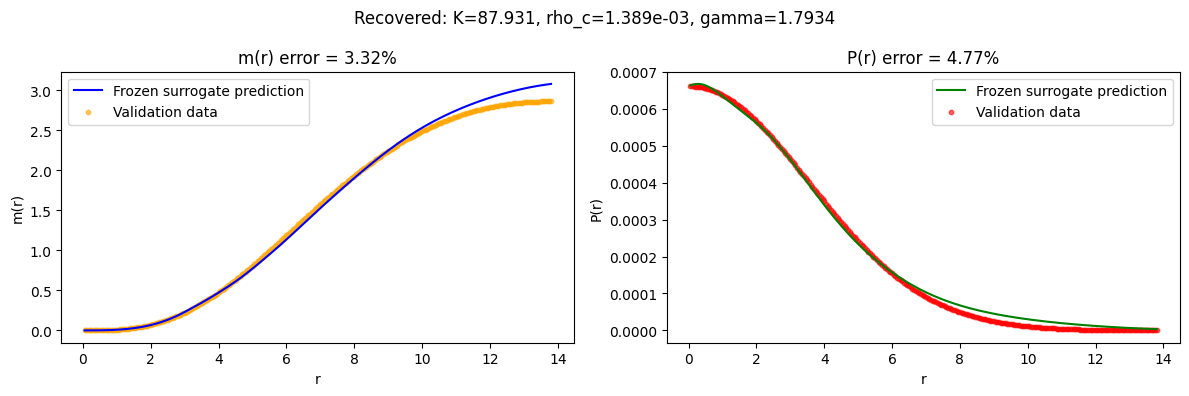


Parameter errors:
K error      = 9.914%
rho_c error  = 7.380%
gamma error  = 0.368%


In [7]:
import tensorflow as tf
tf.keras.backend.set_floatx('float32')

import numpy as np
import matplotlib.pyplot as plt
from IPython import display
import pickle
from scipy.optimize import minimize


with open('tov_surrogate_meta.pkl', 'rb') as f:
    save_bundle = pickle.load(f)

norm_const = {k: tf.constant(v, dtype=tf.float32) for k, v in save_bundle['norm_const'].items()}

K_RANGE = save_bundle['K_range']
RHO_C_RANGE = save_bundle['rho_c_range']
GAMMA_RANGE = save_bundle['gamma_range']

class MassSurrogate(tf.keras.Model):
    def __init__(self, norm_const):
        super().__init__()
        self.trunk = [
            tf.keras.layers.Dense(128, activation='tanh'),
            tf.keras.layers.Dense(128, activation='tanh'),
        ]
        self.head = [
            tf.keras.layers.Dense(64, activation='tanh'),
            tf.keras.layers.Dense(1)
        ]
        self.nc = norm_const

    def call(self, X):
        r_n = X[:, 0:1]
        logK_n = X[:, 1:2]
        logrho_n = X[:, 2:3]
        gamma_n = X[:, 3:4]

        h = X
        for layer in self.trunk:
            h = layer(h)

        for layer in self.head:
            h = layer(h)
        raw_m = h

        logK = logK_n * self.nc['logK_std'] + self.nc['logK_mean']
        logrho = logrho_n * self.nc['logrho_std'] + self.nc['logrho_mean']
        gamma = gamma_n * self.nc['gamma_std'] + self.nc['gamma_mean']

        K = tf.exp(logK)
        rho_c = tf.exp(logrho)
        P_c = K * tf.pow(rho_c, gamma)

        m_n = tf.pow(r_n, 3) * raw_m

        return m_n


class PressureSurrogate(tf.keras.Model):
    def __init__(self, norm_const):
        super().__init__()
        self.trunk = [
            tf.keras.layers.Dense(256, activation='tanh'),
            tf.keras.layers.Dense(256, activation='tanh'),
        ]
        self.head = [
            tf.keras.layers.Dense(256, activation='tanh'),
            tf.keras.layers.Dense(256, activation='tanh'),
            tf.keras.layers.Dense(1)
        ]
        self.nc = norm_const

    def call(self, X):
        r_n = X[:, 0:1]
        logK_n = X[:, 1:2]
        logrho_n = X[:, 2:3]
        gamma_n = X[:, 3:4]

        h = X
        for layer in self.trunk:
            h = layer(h)

        for layer in self.head:
            h = layer(h)

        raw_P = 3.0 * tf.tanh(h)

        logK = logK_n * self.nc['logK_std'] + self.nc['logK_mean']
        logrho = logrho_n * self.nc['logrho_std'] + self.nc['logrho_mean']
        gamma = gamma_n * self.nc['gamma_std'] + self.nc['gamma_mean']

        K = tf.exp(logK)
        rho_c = tf.exp(logrho)
        P_c = K * tf.pow(rho_c, gamma)

        P_ph = P_c * (1.0 - r_n) * tf.exp(r_n * raw_P)
        P_n = P_ph / self.nc['P_scale']

        return P_n

mass_surrogate = MassSurrogate(norm_const)
_ = mass_surrogate(tf.zeros((1, 4), dtype=tf.float32))
mass_surrogate.load_weights('tov_mass_surrogate.weights.h5')
mass_surrogate.trainable = False

pressure_surrogate = PressureSurrogate(norm_const)
_ = pressure_surrogate(tf.zeros((1, 4), dtype=tf.float32))
pressure_surrogate.load_weights('tov_pressure_surrogate.weights.h5')
pressure_surrogate.trainable = False

print("Surrogates loaded and frozen.")


def logit(x):
    return np.log(x / (1.0 - x))


class ParamOnlyFit(tf.keras.Model):
    def __init__(self, mass_surrogate, pressure_surrogate, K_init, rho_c_init, gamma_init, norm_const, K_range, rho_c_range, gamma_range):
        super().__init__()

        self.mass_surrogate = mass_surrogate
        self.mass_surrogate.trainable = False

        self.pressure_surrogate = pressure_surrogate
        self.pressure_surrogate.trainable = False

        self.nc = norm_const

        self.K_min, self.K_max = K_range
        self.rho_min, self.rho_max = rho_c_range
        self.gamma_min, self.gamma_max = gamma_range

        self.logK_min = np.log(self.K_min)
        self.logK_max = np.log(self.K_max)

        self.logrho_min = np.log(self.rho_min)
        self.logrho_max = np.log(self.rho_max)

        K_init = np.clip(K_init, self.K_min, self.K_max)
        rho_c_init = np.clip(rho_c_init, self.rho_min, self.rho_max)
        gamma_init = np.clip(gamma_init, self.gamma_min, self.gamma_max)

        yK = (np.log(K_init) - self.logK_min) / (self.logK_max - self.logK_min)
        yrho = (np.log(rho_c_init) - self.logrho_min) / (self.logrho_max - self.logrho_min)
        ygamma = (gamma_init - self.gamma_min) / (self.gamma_max - self.gamma_min)

        self.K_raw = self.add_weight(shape=(), initializer=tf.keras.initializers.Constant(logit(np.clip(yK, 1e-6, 1 - 1e-6))), dtype=tf.float32, trainable=True, name='K_raw')

        self.rho_raw = self.add_weight(shape=(), initializer=tf.keras.initializers.Constant(logit(np.clip(yrho, 1e-6, 1 - 1e-6))), dtype=tf.float32, trainable=True, name='rho_raw')

        self.gamma_raw = self.add_weight(shape=(), initializer=tf.keras.initializers.Constant(logit(np.clip(ygamma, 1e-6, 1 - 1e-6))), dtype=tf.float32, trainable=True, name='gamma_raw')

    def physics_params(self):
        logK_min = tf.constant(self.logK_min, dtype=tf.float32)
        logK_max = tf.constant(self.logK_max, dtype=tf.float32)
        logK = logK_min + (logK_max - logK_min) * tf.sigmoid(self.K_raw)
        K = tf.exp(logK)

        logrho_min = tf.constant(self.logrho_min, dtype=tf.float32)
        logrho_max = tf.constant(self.logrho_max, dtype=tf.float32)
        logrho = logrho_min + (logrho_max - logrho_min) * tf.sigmoid(self.rho_raw)
        rho_c = tf.exp(logrho)

        gamma_min = tf.constant(self.gamma_min, dtype=tf.float32)
        gamma_max = tf.constant(self.gamma_max, dtype=tf.float32)
        gamma = gamma_min + (gamma_max - gamma_min) * tf.sigmoid(self.gamma_raw)

        return K, rho_c, gamma

    def predict_profile(self, r_phys):
        K, rho_c, gamma = self.physics_params()
        nc = self.nc

        r_n = r_phys / nc['r_scale']

        logK_n = (tf.math.log(K) - nc['logK_mean']) / nc['logK_std']
        logrho_n = (tf.math.log(rho_c) - nc['logrho_mean']) / nc['logrho_std']
        gamma_n = (gamma - nc['gamma_mean']) / nc['gamma_std']

        n = tf.shape(r_n)[0]

        X = tf.stack([r_n, tf.fill([n], logK_n), tf.fill([n], logrho_n), tf.fill([n], gamma_n)], axis=1)

        m_ph = self.mass_surrogate(X) * nc['m_scale']
        P_ph = self.pressure_surrogate(X) * nc['P_scale']

        return m_ph, P_ph


# =====================================================================
# 5. FIT FUNCTION
# =====================================================================

def fit_params_to_validation_star(mass_surrogate, pressure_surrogate, r_data, m_data, P_data, norm_const, K_range, rho_c_range, gamma_range, K_init=100.0, rho_c_init=1.0e-3, gamma_init=2.0, adam_steps=3000,
    bfgs_maxiter=2000,
    plot_every=50,
    m_weight=1.0,
    P_weight=30.0,
    Pc_weight=100.0
):

    fit_model = ParamOnlyFit(mass_surrogate=mass_surrogate, pressure_surrogate=pressure_surrogate, K_init=K_init, rho_c_init=rho_c_init, gamma_init=gamma_init, norm_const=norm_const, K_range=K_range,
        rho_c_range=rho_c_range,
        gamma_range=gamma_range
    )

    print("Trainable variables:", [v.name for v in fit_model.trainable_variables])

    r_tf = tf.constant(r_data, dtype=tf.float32)
    m_obs = tf.constant(m_data.reshape(-1, 1), dtype=tf.float32)
    P_obs = tf.constant(P_data.reshape(-1, 1), dtype=tf.float32)

    opt = tf.keras.optimizers.Adam(1e-2)

    loss_history = []

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

    def compute_loss():
        m_pred, P_pred = fit_model.predict_profile(r_tf)

        K, rho_c, gamma = fit_model.physics_params()
        Pc_pred = K * tf.pow(rho_c, gamma)
        Pc_obs = P_obs[0, 0]

        m_loss = tf.reduce_mean(tf.square((m_pred - m_obs) / (tf.reduce_max(m_obs) + 1e-12)))
        P_loss = tf.reduce_mean(tf.square((P_pred - P_obs) / (Pc_obs + 1e-12)))
        Pc_loss = tf.square((Pc_pred - Pc_obs) / (Pc_obs + 1e-12))

        return m_weight * m_loss + P_weight * P_loss + Pc_weight * Pc_loss

    def update_plot(step, phase, loss_value):
        K_v, rho_v, gamma_v = fit_model.physics_params()

        m_pred, P_pred = fit_model.predict_profile(r_tf)
        m_pred = m_pred.numpy().flatten()
        P_pred = P_pred.numpy().flatten()

        ax1.cla()
        ax1.plot(loss_history)
        ax1.set_yscale('log')
        ax1.set_xlabel('iteration')
        ax1.set_ylabel('loss')
        ax1.set_title(f'{phase} step {step}, loss={loss_value:.3e}')

        ax2.cla()
        ax2.plot(r_data, m_pred, 'b-', label='prediction')
        ax2.scatter(r_data, m_data, s=8, color='orange', alpha=0.6, label='data')
        ax2.set_xlabel('r')
        ax2.set_ylabel('m(r)')
        ax2.legend(fontsize=8)

        ax3.cla()
        ax3.plot(r_data, P_pred, 'g-', label='prediction')
        ax3.scatter(r_data, P_data, s=8, color='red', alpha=0.6, label='data')
        ax3.set_xlabel('r')
        ax3.set_ylabel('P(r)')
        ax3.legend(fontsize=8)

        fig.suptitle(
            f'K={K_v.numpy():.4f}, '
            f'rho_c={rho_v.numpy():.4e}, '
            f'gamma={gamma_v.numpy():.4f}',
            fontsize=11
        )

        plt.tight_layout()
        display.display(fig)
        display.clear_output(wait=True)

    def adam_step():
        with tf.GradientTape() as tape:
            loss = compute_loss()

        grads = tape.gradient(loss, fit_model.trainable_variables)
        opt.apply_gradients(zip(grads, fit_model.trainable_variables))

        return loss

    for step in range(adam_steps):
        loss = adam_step()
        loss_history.append(loss.numpy())

        if step % plot_every == 0:
            update_plot(step, "Adam", loss.numpy())

    def pack():
        return np.array([fit_model.K_raw.numpy(), fit_model.rho_raw.numpy(), fit_model.gamma_raw.numpy()], dtype=np.float64)

    def unpack_and_assign(x):
        fit_model.K_raw.assign(tf.cast(x[0], tf.float32))
        fit_model.rho_raw.assign(tf.cast(x[1], tf.float32))
        fit_model.gamma_raw.assign(tf.cast(x[2], tf.float32))

    def loss_and_grad_np(x):
        unpack_and_assign(x)

        with tf.GradientTape() as tape:
            loss = compute_loss()

        grads = tape.gradient(loss,[fit_model.K_raw, fit_model.rho_raw, fit_model.gamma_raw])

        grad_np = np.array([g.numpy() for g in grads], dtype=np.float64)

        loss_history.append(loss.numpy())

        return loss.numpy().astype(np.float64), grad_np

    bfgs_counter = {'i': 0}

    def bfgs_callback(xk):
        bfgs_counter['i'] += 1

        if bfgs_counter['i'] % max(1, plot_every // 10) == 0:
            unpack_and_assign(xk)
            update_plot(bfgs_counter['i'], "L-BFGS", loss_history[-1])

    x0 = pack()

    res = minimize(fun=loss_and_grad_np, x0=x0, jac=True, method='L-BFGS-B', options={'maxiter': bfgs_maxiter}, callback=bfgs_callback)

    unpack_and_assign(res.x)

    plt.close(fig)

    K_final, rho_c_final, gamma_final = fit_model.physics_params()

    return fit_model, (K_final.numpy(), rho_c_final.numpy(), gamma_final.numpy()), loss_history


# Generate validation star
true_K = 80.0
true_rho_c = 1.5e-3
true_gamma = 1.8

r_new, m_new, P_new, M_true, R_true = gen_tov_data(rho_c=true_rho_c, K=true_K, gamma=true_gamma, dr=0.05, r_max=15)

print("Generated validation data.")
print(f"True parameters: K={true_K}, rho_c={true_rho_c}, gamma={true_gamma}")

fit_model, (K_rec, rho_c_rec, gamma_rec), loss_history = fit_params_to_validation_star(mass_surrogate=mass_surrogate, pressure_surrogate=pressure_surrogate,
    r_data=r_new,
    m_data=m_new,
    P_data=P_new,
    norm_const=norm_const,
    K_range=K_RANGE,
    rho_c_range=RHO_C_RANGE,
    gamma_range=GAMMA_RANGE,
    K_init=100.0,
    rho_c_init=1.2e-3,
    gamma_init=1.6,
    adam_steps=500,
    bfgs_maxiter=3000,
    plot_every=50,
    m_weight=1.0,
    P_weight=30.0,
    Pc_weight=100.0
)

print("\nRecovered parameters:")
print(f"K      = {K_rec:.6f}")
print(f"rho_c  = {rho_c_rec:.6e}")
print(f"gamma  = {gamma_rec:.6f}")

# Final profile plot
r_tf = tf.constant(r_new, dtype=tf.float32)
m_pred_tf, P_pred_tf = fit_model.predict_profile(r_tf)
m_pred = m_pred_tf.numpy().flatten()
P_pred = P_pred_tf.numpy().flatten()

m_error = np.mean(np.abs(m_pred - m_new)) / np.mean(m_new) * 100
P_error = np.mean(np.abs(P_pred - P_new)) / np.mean(P_new) * 100

print("\nProfile errors:")
print(f"m(r) mean relative error = {m_error:.3f}%")
print(f"P(r) mean relative error = {P_error:.3f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(r_new, m_pred, 'b-', label='Frozen surrogate prediction')
ax1.scatter(r_new, m_new, s=10, color='orange', alpha=0.6, label='Validation data')
ax1.set_xlabel('r')
ax1.set_ylabel('m(r)')
ax1.set_title(f'm(r) error = {m_error:.2f}%')
ax1.legend()

ax2.plot(r_new, P_pred, 'g-', label='Frozen surrogate prediction')
ax2.scatter(r_new, P_new, s=10, color='red', alpha=0.6, label='Validation data')
ax2.set_xlabel('r')
ax2.set_ylabel('P(r)')
ax2.set_title(f'P(r) error = {P_error:.2f}%')
ax2.legend()

plt.suptitle(f'Recovered: K={K_rec:.3f}, rho_c={rho_c_rec:.3e}, gamma={gamma_rec:.4f}', fontsize=12)

plt.tight_layout()
plt.show()


if 'true_K' in globals() and 'true_rho_c' in globals() and 'true_gamma' in globals():
    print("\nParameter errors:")
    print(f"K error      = {abs(K_rec - true_K) / true_K * 100:.3f}%")
    print(f"rho_c error  = {abs(rho_c_rec - true_rho_c) / true_rho_c * 100:.3f}%")
    print(f"gamma error  = {abs(gamma_rec - true_gamma) / true_gamma * 100:.3f}%")